# EDA song ngữ Trung–Việt (TMĐT) + Similarity bằng BAAI/bge-m3

**Input:** `bilingual_zh_vi.parquet` (~16K cặp sản phẩm TMĐT Trung–Việt)
**Mô hình:** [BAAI/bge-m3](https://huggingface.co/BAAI/bge-m3) — gọi thẳng từ Hugging Face Hub qua thư viện `transformers`.
**Công cụ:** pandas + pyarrow (EDA) · transformers + torch (embedding)

> ⚠️ **Schema thực tế:** file **không** có cột `zh_text` / `vi_text` như giả định ban đầu.
> Các cột văn bản thực tế là `title_zh`, `title_vi`, `description_zh`, `description_vi`.
> Notebook tự động dò cột (auto-detect) nên chạy được với cả 2 kiểu schema.


In [11]:
# Cài thư viện (chỉ cần trên Colab / máy chưa có). Bỏ qua nếu đã cài.
%pip install -q transformers torch pandas pyarrow matplotlib


## 0. Cài đặt & Import


In [12]:
import re
import hashlib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

# Nguồn dữ liệu: Hugging Face (đọc trực tiếp qua HTTPS).
# Muốn dùng file local thì đổi lại thành "bilingual_zh_vi.parquet".
HF_REPO = "ntquang0410/zh-vie_ecom"
HF_FILE = "data/snapshot/bilingual_zh_vi.parquet"
PARQUET_PATH = f"https://huggingface.co/datasets/{HF_REPO}/resolve/main/{HF_FILE}"

print("pandas", pd.__version__, "| torch", torch.__version__)


pandas 2.2.3 | torch 2.11.0+cu128


## 1. Tổng quan (shape, dtypes, null)


In [13]:
def load_parquet(path):
    """Đọc parquet từ URL hoặc đường dẫn local, fallback duckdb nếu pandas lỗi."""
    try:
        return pd.read_parquet(path)
    except ImportError as e:
        print("pandas thiếu thư viện, fallback duckdb:", e)
    except Exception as e:
        print("pandas lỗi:", type(e).__name__, e)
    import duckdb
    return duckdb.sql(f"SELECT * FROM read_parquet('{path}')").df()

df = load_parquet(PARQUET_PATH)

print("shape:", df.shape)
print("\n--- dtypes ---")
print(df.dtypes.to_string())
print("\n--- 5 dòng đầu ---")
display(df.head())

# --- Đếm null / rỗng theo từng cột (%) ---
# Cột nested (list/struct như attributes_zh) khi astype(str) ra "[]" chứ không rỗng,
# nên phải loại chúng khỏi phép đếm "rỗng" để tránh báo sai.
def is_text_col(s):
    return pd.api.types.is_string_dtype(s) or s.dtype == object

def is_nested_col(s):
    return s.map(type).isin([list, dict]).any()

def null_report(frame):
    rows = []
    n = len(frame)
    for c in frame.columns:
        s = frame[c]
        n_null = int(s.isna().sum())
        n_empty = 0
        if is_text_col(s) and not is_nested_col(s):
            try:
                n_empty = int(s.fillna("").astype(str).str.strip().eq("").sum())
            except Exception:
                n_empty = 0
        rows.append({
            "column": c,
            "dtype": str(s.dtype),
            "null_%": round(100 * n_null / n, 2),
            "empty_%": round(100 * n_empty / n, 2),
        })
    return pd.DataFrame(rows).sort_values("null_%", ascending=False)

null_df = null_report(df)
print("\n--- Null / rỗng theo cột (chỉ in cột có vấn đề) ---")
display(null_df[null_df["null_%"] > 0].reset_index(drop=True))
print("Số cột có null:", int((null_df["null_%"] > 0).sum()), "/", len(null_df))


shape: (16348, 30)

--- dtypes ---
product_id               object
title_zh                 object
title_vi                 object
description_zh           object
description_vi           object
category                 object
source_site              object
url                      object
crawl_time               object
worker                   object
keyword                  object
page                      int64
search_url               object
price                   float64
sales                   float64
province                 object
city                     object
biz_type                 object
shop                     object
is_ad                      bool
category_1688            object
category_id_1688         object
has_vi                     bool
attributes_zh            object
attributes_vi            object
n_attributes_zh           int64
n_attributes_vi           int64
n_attributes_aligned      int64
description_extra_zh     object
description_images        int64

--- 

,product_id,title_zh,title_vi,description_zh,description_vi,category,source_site,url,crawl_time,worker,...,category_1688,category_id_1688,has_vi,attributes_zh,attributes_vi,n_attributes_zh,n_attributes_vi,n_attributes_aligned,description_extra_zh,description_images
0,592582928262,轮胎刷 风口刷 轮毂刷发动机刷细节刷缝隙刷洗车清洁小毛刷洗车刷,"Bàn chải lốp, bàn chải cửa gió, bàn chải trung tâm, bàn chải động cơ, bàn ch...","材质: 超细纤维; 品牌: 柏尼士; 产地: 广州; 货号: 洗车刷子系列; 颜色: 1号竹柄刷, 2号圆头刷好, 3号黑色圆头刷, 4号小尖头刷, 5...",Chất liệu: sợi nhỏ; Thương hiệu: Perniz; Xuất xứ: Quảng Châu; Số mặt hàng: D...,auto,1688,https://detail.1688.com/offer/592582928262.html,2026-09-17T19:28:45+00:00,worker_nhat_anh,...,汽车清洁工具,124742030,True,"[{'name': '材质', 'values': ['超细纤维']}, {'name': '品牌', 'values': ['柏尼士']}, {'na...","[{'name': 'Chất liệu', 'values': ['sợi nhỏ']}, {'name': 'Xuất xứ', 'values':...",11,11,11,,12
1,741400188461,汽车座椅后背收纳袋可爱卡通车载垃圾桶创意多功能汽车内饰防踢垫,"Túi đựng đồ phía sau ghế ô tô, thùng rác ô tô hoạt hình dễ thương, đệm chống...","材质: 皮革; 功能: 防水, 抗压, 可定制, 带提手; 使用位置: 座椅后背; 适用汽车品牌: 通用; 品牌: 羽岑; 使用方式: 悬挂式; 加工定...","Chất liệu: Da; Chức năng: Chống nước, Chống nén, Có thể tùy chỉnh, Có tay cầ...",auto,1688,https://detail.1688.com/offer/741400188461.html,2026-09-17T19:29:06+00:00,worker_nhat_anh,...,车用置物袋/置物箱,1032116,True,"[{'name': '材质', 'values': ['皮革']}, {'name': '功能', 'values': ['防水', '抗压', '可定...","[{'name': 'Thương hiệu', 'values': ['Vũ Cen']}, {'name': 'Chất liệu', 'value...",17,17,17,,20
2,916030328790,汽车临时停车牌女挪车电话牌车载手机号码牌创意摆件装饰用品大全,Biển báo đỗ xe ô tô tạm thời Biển báo điện thoại di động ô tô biển số điện t...,材质: 塑料; 品牌: other/其他; 类型: 隐藏式; 产地: 义乌; 加工定制: 否; 尺寸: 15; 型号: 0003; 适用送礼场合: 其他...,Chất liệu: Nhựa; Thương hiệu: Khác/khác; Loại: Kiểu ẩn; Xuất xứ: Nghĩa Ô; Gi...,auto,1688,https://detail.1688.com/offer/916030328790.html,2026-09-17T19:29:27+00:00,worker_nhat_anh,...,临时停车牌,201327101,True,"[{'name': '材质', 'values': ['塑料']}, {'name': '品牌', 'values': ['other/其他']}, {...","[{'name': 'Thương hiệu', 'values': ['Khác/khác']}, {'name': 'Chất liệu', 'va...",15,15,15,,6
3,789617923790,厂家批发车载停车牌隐藏式挪车金属号码牌夜光创意摆件汽车用品,Nhà sản xuất bán buôn tấm đỗ xe ô tô ẩn tấm số kim loại di chuyển ô tô dạ qu...,材质: 金属; 功能: 夜光; 品牌: 登驿诺; 类型: 隐藏式; 产地: 中国地区; 加工定制: 是; 尺寸: 125*18mm; 型号: 汽车隐藏式...,Chất liệu: Kim loại; chức năng: Phát sáng trong bóng tối; Thương hiệu: Dengn...,auto,1688,https://detail.1688.com/offer/789617923790.html,2026-09-17T19:29:46+00:00,worker_nhat_anh,...,临时停车牌,201327101,True,"[{'name': '材质', 'values': ['金属']}, {'name': '功能', 'values': ['夜光']}, {'name'...","[{'name': 'Thương hiệu', 'values': ['Dengnuo']}, {'name': 'Chất liệu', 'valu...",16,16,16,,18
4,859282894083,汽车摆件五星红旗党旗车载装饰用品伸缩 小红旗汽车香水工厂代发,Đồ trang trí ô tô Cờ đỏ năm sao Cờ đảng Đồ trang trí ô tô có thể thu vào Nhà...,风格: 中国传统; 材质: 玻璃; 功能: 祝福; 品牌: santigo; 加工定制: 是; 是否专利货源: 否; 货号: 旗帜摆件; 颜色分类: 金...,Phong cách: Truyền thống Trung Quốc; Chất liệu: Thủy tinh; Chức năng: Chúc p...,auto,1688,https://detail.1688.com/offer/859282894083.html,2026-09-17T19:30:12+00:00,worker_nhat_anh,...,汽车摆件,125086011,True,"[{'name': '风格', 'values': ['中国传统']}, {'name': '材质', 'values': ['玻璃']}, {'nam...","[{'name': 'Chất liệu', 'values': ['Thủy tinh']}, {'name': 'Phong cách', 'val...",9,9,9,,17



--- Null / rỗng theo cột (chỉ in cột có vấn đề) ---


,column,dtype,null_%,empty_%
0,biz_type,object,16.50,16.50
1,sales,float64,3.32,0.00
2,city,object,0.10,0.10
3,province,object,0.01,0.01


Số cột có null: 4 / 30


## 2. Thống kê văn bản (độ dài ký tự & token)


Cột zh dùng để phân tích: title_zh
Cột vi dùng để phân tích: title_vi

--- Thống kê độ dài (ký tự) ---


,zh_chars,vi_chars
count,16348.0,16348.0
mean,31.2,125.0
std,2.7,23.8
min,3.0,5.0
50%,31.0,124.0
95%,36.0,164.0
99%,42.0,191.0
max,55.0,270.0


--- Thống kê token ước lượng ---


,zh_tokens,vi_tokens
count,16348.0,16348.0
mean,31.1,27.8
std,2.6,5.3
min,3.0,1.0
50%,30.0,28.0
95%,36.0,36.0
99%,41.0,43.0
max,48.0,63.0


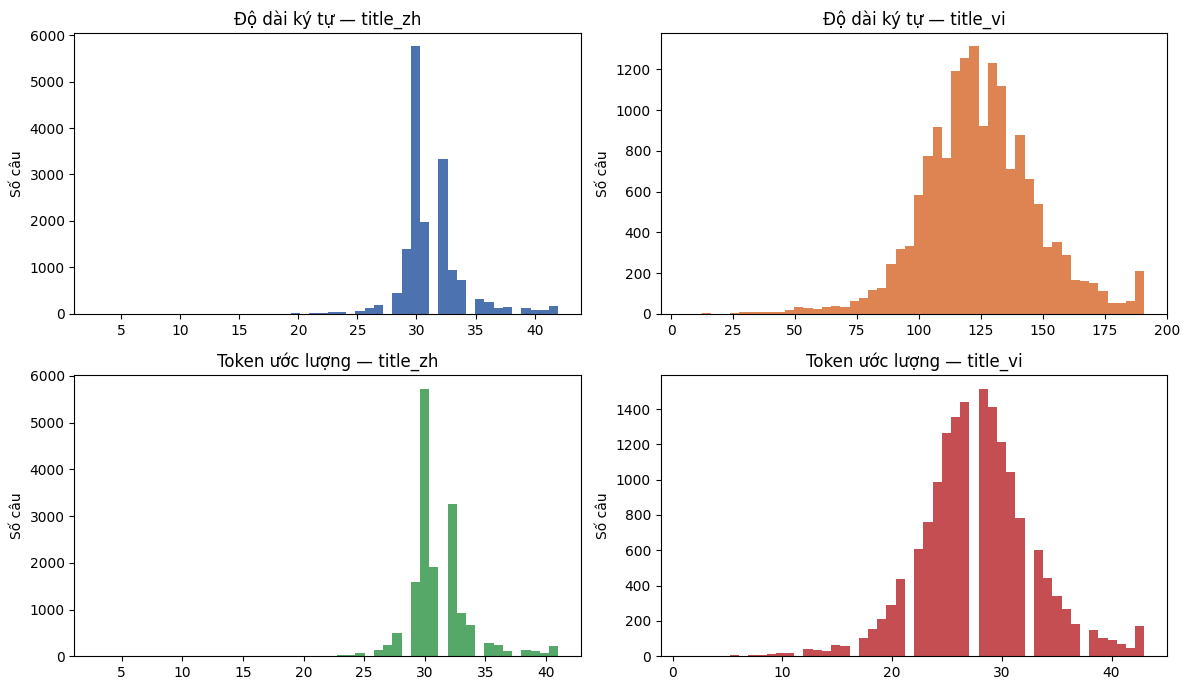


--- Tỷ lệ độ dài KÝ TỰ (vi/zh) ---
count    16348.000
mean         4.030
std          0.828
min          0.500
50%          4.000
95%          5.400
99%          6.333
max         10.077

--- Tỷ lệ TOKEN (vi_words / zh_chars) — dùng để phát hiện lệch ---
count    16348.000
mean         0.900
std          0.186
min          0.029
50%          0.900
95%          1.200
99%          1.414
max          2.192

Outlier theo tỷ lệ KÝ TỰ (>3.0 hoặc <0.3): 14906 (91.2%)  <- ngưỡng không phù hợp với zh->vi
Outlier theo tỷ lệ TOKEN  (>3.0 hoặc <0.3): 29 (0.18%)  <- dùng cái này


In [14]:
def is_flat_text(s):
    if not (pd.api.types.is_string_dtype(s) or s.dtype == object):
        return False
    return not s.map(type).isin([list, dict]).any()

def pick_col(frame, candidates):
    for c in candidates:
        if c in frame.columns and is_flat_text(frame[c]):
            return c
    return None

ZH_COL = pick_col(df, ["zh_text", "title_zh", "description_zh"])
VI_COL = pick_col(df, ["vi_text", "title_vi", "description_vi"])
print("Cột zh dùng để phân tích:", ZH_COL)
print("Cột vi dùng để phân tích:", VI_COL)

# Token ước lượng: tiếng Trung ~ 1 ký tự = 1 token; tiếng Việt ~ tách theo khoảng trắng
def est_tokens_zh(s):
    return s.fillna("").astype(str).str.replace(r"\s+", "", regex=True).str.len()

def est_tokens_vi(s):
    return s.fillna("").astype(str).str.split().str.len()

try:
    len_zh = df[ZH_COL].fillna("").astype(str).str.len()
    len_vi = df[VI_COL].fillna("").astype(str).str.len()
    tok_zh = est_tokens_zh(df[ZH_COL])
    tok_vi = est_tokens_vi(df[VI_COL])
except Exception as e:
    print("Lỗi tính độ dài:", e)
    len_zh = len_vi = tok_zh = tok_vi = pd.Series(dtype=float)

print("\n--- Thống kê độ dài (ký tự) ---")
display(pd.DataFrame({
    "zh_chars": len_zh.describe(percentiles=[.5, .95, .99]),
    "vi_chars": len_vi.describe(percentiles=[.5, .95, .99]),
}).round(1))

print("--- Thống kê token ước lượng ---")
display(pd.DataFrame({
    "zh_tokens": tok_zh.describe(percentiles=[.5, .95, .99]),
    "vi_tokens": tok_vi.describe(percentiles=[.5, .95, .99]),
}).round(1))

# --- Histogram cơ bản ---
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].hist(len_zh.clip(upper=len_zh.quantile(.99)), bins=50, color="#4C72B0")
axes[0, 0].set_title(f"Độ dài ký tự — {ZH_COL}")
axes[0, 1].hist(len_vi.clip(upper=len_vi.quantile(.99)), bins=50, color="#DD8452")
axes[0, 1].set_title(f"Độ dài ký tự — {VI_COL}")
axes[1, 0].hist(tok_zh.clip(upper=tok_zh.quantile(.99)), bins=50, color="#55A868")
axes[1, 0].set_title(f"Token ước lượng — {ZH_COL}")
axes[1, 1].hist(tok_vi.clip(upper=tok_vi.quantile(.99)), bins=50, color="#C44E52")
axes[1, 1].set_title(f"Token ước lượng — {VI_COL}")
for ax in axes.ravel():
    ax.set_ylabel("Số câu")
plt.tight_layout()
plt.show()

# --- Tỷ lệ độ dài zh/vi ---
# Tỷ lệ KÝ TỰ vi/zh luôn ~4.0 (tiếng Việt nhiều ký tự hơn) -> ngưỡng >3.0/<0.3 flag ~91%.
# => Dùng tỷ lệ TOKEN (số từ vi / số ký tự zh), kỳ vọng ~0.9.
ratio_char = (len_vi / len_zh.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
ratio_tok = (tok_vi / tok_zh.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

print("\n--- Tỷ lệ độ dài KÝ TỰ (vi/zh) ---")
print(ratio_char.describe(percentiles=[.5, .95, .99]).round(3).to_string())
print("\n--- Tỷ lệ TOKEN (vi_words / zh_chars) — dùng để phát hiện lệch ---")
print(ratio_tok.describe(percentiles=[.5, .95, .99]).round(3).to_string())

RATIO_HI, RATIO_LO = 3.0, 0.3
n_char_out = int(((ratio_char > RATIO_HI) | (ratio_char < RATIO_LO)).sum())
n_tok_out = int(((ratio_tok > RATIO_HI) | (ratio_tok < RATIO_LO)).sum())
print(f"\nOutlier theo tỷ lệ KÝ TỰ (>{RATIO_HI} hoặc <{RATIO_LO}): {n_char_out} "
      f"({100*n_char_out/len(df):.1f}%)  <- ngưỡng không phù hợp với zh->vi")
print(f"Outlier theo tỷ lệ TOKEN  (>{RATIO_HI} hoặc <{RATIO_LO}): {n_tok_out} "
      f"({100*n_tok_out/len(df):.2f}%)  <- dùng cái này")


## 3. Từ vựng & thuật ngữ TMĐT


In [15]:
# --- Top 30 token phổ biến mỗi ngôn ngữ (lowercase + strip) ---
def top_tokens(series, n=30, lang="vi"):
    txt = series.fillna("").astype(str).str.lower().str.strip()
    if lang == "zh":
        # tiếng Trung: tách theo ký tự Hán (bỏ khoảng trắng & dấu câu)
        toks = txt.str.findall(r"[\u4e00-\u9fff]")
    else:
        toks = txt.str.findall(r"\w+", flags=re.UNICODE)
    cnt = Counter(t for row in toks for t in row)
    return pd.DataFrame(cnt.most_common(n), columns=["token", "count"])

try:
    print(f"--- Top 30 token ZH ({ZH_COL}) ---")
    display(top_tokens(df[ZH_COL], 30, "zh"))
    print(f"--- Top 30 token VI ({VI_COL}) ---")
    display(top_tokens(df[VI_COL], 30, "vi"))
except Exception as e:
    print("Lỗi thống kê từ vựng:", e)

# --- Ký tự HTML còn sót ---
HTML_PATTERNS = {
    "entity (&amp; &lt; &gt; &quot; &#...);": r"&(?:amp|lt|gt|quot|nbsp|#\d+);",
    "tag (<...>)": r"<[^>]{1,80}>",
    "url (http/https)": r"https?://",
}
print("\n--- Ký tự HTML / URL còn sót ---")
rows = []
for name, pat in HTML_PATTERNS.items():
    for col in [c for c in [ZH_COL, VI_COL] if c]:
        try:
            n = int(df[col].fillna("").astype(str).str.contains(pat, regex=True).sum())
        except Exception:
            n = -1
        rows.append({"pattern": name, "column": col, "rows": n})
display(pd.DataFrame(rows))

# --- Thuật ngữ TMĐT ---
ZH_TERMS = ["包邮", "正品", "代购", "旗舰店", "促销", "折扣"]
VI_TERMS = ["freeship", "chính hãng", "khuyến mãi", "giảm giá", "ship", "sale"]

def count_terms(frame, terms, cols):
    out = []
    for t in terms:
        row = {"term": t}
        for c in cols:
            if c is None:
                continue
            try:
                row[c] = int(frame[c].fillna("").astype(str).str.lower()
                             .str.contains(re.escape(t.lower()), regex=True).sum())
            except Exception:
                row[c] = -1
        out.append(row)
    return pd.DataFrame(out)

print("\n--- Thuật ngữ TMĐT tiếng Trung ---")
ZH_TEXT_COLS = [c for c in df.columns if c.endswith("_zh") and is_flat_text(df[c])]
display(count_terms(df, ZH_TERMS, ZH_TEXT_COLS))
print("--- Thuật ngữ TMĐT tiếng Việt ---")
VI_TEXT_COLS = [c for c in df.columns if c.endswith("_vi") and is_flat_text(df[c])]
display(count_terms(df, VI_TERMS, VI_TEXT_COLS))


--- Top 30 token ZH (title_zh) ---


,token,count
0,包,9628
1,鞋,7453
2,款,6978
3,新,6236
4,女,5634
5,男,5522
6,套,4301
7,衣,3765
8,面,3729
9,茶,3671


--- Top 30 token VI (title_vi) ---


,token,count
0,cho,7287
1,giày,6392
2,đồ,5509
3,mới,5049
4,túi,4972
5,áo,4793
6,bộ,4715
7,nam,4539
8,nữ,4479
9,và,4469



--- Ký tự HTML / URL còn sót ---


,pattern,column,rows
0,entity (&amp; &lt; &gt; &quot; &#...);,title_zh,0
1,entity (&amp; &lt; &gt; &quot; &#...);,title_vi,0
2,tag (<...>),title_zh,0
3,tag (<...>),title_vi,0
4,url (http/https),title_zh,0
5,url (http/https),title_vi,0



--- Thuật ngữ TMĐT tiếng Trung ---


,term,title_zh,description_zh,attributes_zh,description_extra_zh
0,包邮,57,20,20,59
1,正品,214,22,22,91
2,代购,4,0,0,11
3,旗舰店,35,7,7,9
4,促销,1,77,77,34
5,折扣,1,0,0,29


--- Thuật ngữ TMĐT tiếng Việt ---


,term,title_vi,description_vi,attributes_vi
0,freeship,0,0,0
1,chính hãng,263,77,77
2,khuyến mãi,5,68,68
3,giảm giá,14,21,21
4,ship,95,90,90
5,sale,1,5,5


## 4. Trùng lặp


In [16]:
# LƯU Ý: df.duplicated() trên TOÀN BỘ frame sẽ lỗi nếu có cột nested (list/struct)
# như attributes_zh / attributes_vi -> phải giới hạn ở các cột văn bản.
TEXT_COLS = [c for c in [ZH_COL, VI_COL] if c]
PAIR_COLS = [c for c in ["title_zh", "title_vi", "description_zh", "description_vi"] if c in df.columns]

def dup_count(frame, cols, label):
    try:
        n = int(frame[cols].duplicated(keep="first").sum())
    except Exception as e:
        n = -1
        print(f"  ! {label}: {e}")
    print(f"{label:<42} {n:>7}  ({100*n/len(frame):.2f}%)")
    return n

print("--- Đếm trùng lặp ---")
dup_pair = dup_count(df, TEXT_COLS, f"Cặp trùng chính xác {TEXT_COLS}")
dup_full = dup_count(df, PAIR_COLS, "Trùng toàn bộ 4 cột văn bản")
dup_zh = dup_count(df, [ZH_COL], f"Câu ZH trùng ({ZH_COL})")
dup_vi = dup_count(df, [VI_COL], f"Câu VI trùng ({VI_COL})")
if "product_id" in df.columns:
    dup_count(df, ["product_id"], "product_id trùng")

# Kiểm chứng bằng hashlib (md5) trên cặp câu -> phải khớp với df.duplicated()
try:
    h = (df[ZH_COL].fillna("").astype(str) + "\x1f" + df[VI_COL].fillna("").astype(str)) \
        .map(lambda s: hashlib.md5(s.encode("utf-8")).hexdigest())
    print(f"\nHash md5 trùng (kiểm chứng): {int(h.duplicated().sum())}  "
          f"-> khớp với df.duplicated(): {int(h.duplicated().sum()) == dup_pair}")
except Exception as e:
    print("Lỗi hash:", e)

if dup_pair > 0:
    print("\n--- Ví dụ cặp trùng ---")
    display(df[df[TEXT_COLS].duplicated(keep=False)].sort_values(TEXT_COLS).head(6))


--- Đếm trùng lặp ---
Cặp trùng chính xác ['title_zh', 'title_vi']     211  (1.29%)
Trùng toàn bộ 4 cột văn bản                      7  (0.04%)
Câu ZH trùng (title_zh)                        485  (2.97%)
Câu VI trùng (title_vi)                        217  (1.33%)
product_id trùng                                 0  (0.00%)

Hash md5 trùng (kiểm chứng): 211  -> khớp với df.duplicated(): True

--- Ví dụ cặp trùng ---


,product_id,title_zh,title_vi,description_zh,description_vi,category,source_site,url,crawl_time,worker,...,category_1688,category_id_1688,has_vi,attributes_zh,attributes_vi,n_attributes_zh,n_attributes_vi,n_attributes_aligned,description_extra_zh,description_images
5961,898564855686,100%纯棉春夏装痞帅情侣装男复古港味ins字母短袖T恤新款宽松半袖,100% cotton quần áo mùa xuân và mùa hè quần áo cặp đôi đẹp trai áo phông ngắ...,主面料成分: 涤纶（聚酯纤维）; 面料名称: 纯棉; 款式: 套头; 工艺: 印花/印染; 适合人群: 青少年; 类别: 短袖T恤; 风格: 港风; 货...,Thành phần vải chính: Polyester (sợi polyester); Tên vải: 100% cotton; Kiểu ...,fashion,1688,https://detail.1688.com/offer/898564855686.html,2026-09-20T05:23:12+00:00,worker_huy,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['涤纶（聚酯纤维）']}, {'name': '面料名称', 'values': ['纯棉'...","[{'name': 'Phong cách', 'values': ['Phong cách Hồng Kông']}, {'name': 'Số mặ...",33,33,33,,9
5967,899141990675,100%纯棉春夏装痞帅情侣装男复古港味ins字母短袖T恤新款宽松半袖,100% cotton quần áo mùa xuân và mùa hè quần áo cặp đôi đẹp trai áo phông ngắ...,主面料成分: 涤纶（聚酯纤维）; 面料名称: 纯棉; 款式: 套头; 工艺: 印花/印染; 适合人群: 青少年; 类别: 短袖T恤; 风格: 港风; 货...,Thành phần vải chính: Polyester (sợi polyester); Tên vải: 100% cotton; Kiểu ...,fashion,1688,https://detail.1688.com/offer/899141990675.html,2026-09-20T05:24:09+00:00,worker_huy,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['涤纶（聚酯纤维）']}, {'name': '面料名称', 'values': ['纯棉'...","[{'name': 'Phong cách', 'values': ['Phong cách Hồng Kông']}, {'name': 'Số mặ...",33,33,33,,13
8961,899700624386,100%纯棉春夏装痞帅情侣装男复古港味ins字母短袖T恤新款宽松半袖,100% cotton quần áo mùa xuân và mùa hè quần áo cặp đôi đẹp trai áo phông ngắ...,主面料成分: 纯棉; 面料名称: 纯棉; 款式: 套头; 品牌: 其他; 工艺: 印花/印染; 适合人群: 青少年; 类别: 圆领T恤; 风格: 港风;...,Thành phần vải chính: 100% cotton1; Tên vải: 100% cotton2; Kiểu dáng: Chui đ...,fashion,1688,https://detail.1688.com/offer/899700624386.html,2026-09-20T04:35:41+00:00,worker_nhat_anh,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['纯棉']}, {'name': '面料名称', 'values': ['纯棉']}, {'...","[{'name': 'Phong cách', 'values': ['Phong cách Hồng Kông']}, {'name': 'Số mặ...",37,37,37,,7
9393,901099727232,100%纯棉春夏装痞帅情侣装男复古港味ins字母短袖T恤新款宽松半袖,100% cotton quần áo mùa xuân và mùa hè quần áo cặp đôi đẹp trai áo phông ngắ...,主面料成分: 棉; 面料名称: 纯棉; 款式: 套头; 品牌: 渝泽服装厂; 工艺: 印花/印染; 适合人群: 青年; 类别: 短袖T恤; 风格: 国潮...,Thành phần vải chính: Bông; Tên vải: 100% cotton; Kiểu dáng: Chui đầu; Thươn...,fashion,1688,https://detail.1688.com/offer/901099727232.html,2026-09-20T07:18:58+00:00,worker_nhat_anh,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['棉']}, {'name': '面料名称', 'values': ['纯棉']}, {'n...","[{'name': 'Phong cách', 'values': ['Quốc triều']}, {'name': 'Số mặt hàng', '...",33,33,33,,12
6078,903729007320,100%纯棉百搭短袖t恤男2026新款夏季潮牌小众高街美式宽松上衣ins,"Áo thun nam tay ngắn 100% cotton nguyên chất, đa năng, thời trang hè 2026, t...",主面料成分: 棉; 面料名称: 纯棉; 款式: 套头; 品牌: 其他; 工艺: 免烫处理; 适合人群: 大码; 类别: T恤背心; 风格: 基础大众; ...,Thành phần vải chính: Bông; Tên vải: 100% cotton; Kiểu dáng: Chui đầu; Thươn...,fashion,1688,https://detail.1688.com/offer/903729007320.html,2026-09-20T07:07:00+00:00,worker_huy,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['棉']}, {'name': '面料名称', 'values': ['纯棉']}, {'n...","[{'name': 'Phong cách', 'values': ['Volkswagen cơ bản']}, {'name': 'Số mặt h...",37,37,37,,37
9002,897952027974,100%纯棉百搭短袖t恤男2026新款夏季潮牌小众高街美式宽松上衣ins,"Áo thun nam tay ngắn 100% cotton nguyên chất, đa năng, thời trang hè 2026, t...",主面料成分: 棉; 面料名称: 纯棉; 款式: 套头; 品牌: 其他; 工艺: 印花/印染; 适合人群: 青少年; 类别: T恤背心; 风格: 基础大众...,Thành phần vải chính: bông; Tên vải: bông nguyên chất; phong cách: áo thun1;...,fashion,1688,https://detail.1688.com/offer/897952027974.html,2026-09-20T04:52:22+00:00,worker_nhat_anh,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['棉']}, {'name': '面料名称', 'values': ['纯棉']}, {'n...","[{'name': 'phong cách', 'values': ['Khối lượng cơ bản']}, {'name': 'phong cá...",36,36,36,,11


## 5. Similarity Trung–Việt bằng BAAI/bge-m3 (từ Hugging Face)

Gọi thẳng mô hình `BAAI/bge-m3` từ Hugging Face Hub qua thư viện `transformers`
(`AutoTokenizer` + `AutoModel`), dùng **CLS pooling** + **chuẩn hoá L2** (đúng theo
`1_Pooling/config.json`) → cosine similarity = tích vô hướng.

Một con số similarity đứng riêng **không nói được** bản dịch tốt hay xấu, nên mục này làm theo thứ tự:

| Mục | Việc | Vì sao |
|---|---|---|
| 5.1 | Tính cho **toàn bộ** title, không lấy mẫu | Kết luận phải dựa trên cả tập, không phải 12% |
| 5.2 | **Mốc nền**: điểm của các cặp chắc chắn sai → đặt ngưỡng | Ngưỡng 0.5 chọn tay không có căn cứ |
| 5.3 | Xếp hạng **trong từng category** + file đọc tay | Trà/đồ ăn nhiều tên riêng phiên âm nên điểm thấp sẵn |
| 5.4 | **Chữ Hán còn sót** trong cột tiếng Việt | Dòng chưa dịch lại được điểm similarity cao |
| 5.5 | **Description** theo từng cặp thuộc tính | Lỗi nặng nhất nằm ở description, không phải title |

In [17]:
# --- Nạp bge-m3 thẳng từ Hugging Face Hub ---
MODEL_NAME = "BAAI/bge-m3"

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print("Thiết bị:", DEVICE)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

def encode(texts, max_length=512, batch_size=64):
    """Encode danh sách văn bản -> tensor (n, 1024) đã chuẩn hoá L2."""
    if isinstance(texts, str):
        texts = [texts]
    texts = ["" if t is None else str(t) for t in texts]
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_length, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = model(**enc)
        # CLS pooling (đúng cấu hình bge-m3)
        e = out.last_hidden_state[:, 0, :]
        e = F.normalize(e, p=2, dim=1)
        embs.append(e.cpu())
    return torch.cat(embs, dim=0)

def encode_np(texts, batch_size=128, **kw):
    """encode() -> numpy (n, 1024). Sắp xếp theo độ dài trước khi chia batch để giảm padding
    (nhanh hơn nhiều khi độ dài chênh lệch lớn), rồi trả lại đúng thứ tự ban đầu."""
    texts = ["" if t is None else str(t) for t in texts]
    if not texts:
        return np.zeros((0, 1024), dtype=np.float32)
    order = np.argsort([len(t) for t in texts], kind="stable")
    emb = encode([texts[i] for i in order], batch_size=batch_size, **kw).numpy().astype(np.float32)
    out = np.empty_like(emb)
    out[order] = emb
    return out

Thiết bị: cuda


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

### 5.1 Similarity cho toàn bộ title

In [18]:
# --- 5.1 Similarity cho TOÀN BỘ title (không lấy mẫu) ---
# Muốn chạy thử nhanh thì đặt SAMPLE = 2000; kết luận chính thức phải chạy SAMPLE = None.
SAMPLE = None

work = df[[c for c in ["product_id", "category", ZH_COL, VI_COL] if c in df.columns]].copy()
work[ZH_COL] = work[ZH_COL].fillna("").astype(str)
work[VI_COL] = work[VI_COL].fillna("").astype(str)
if "category" not in work.columns:
    work["category"] = "all"
if SAMPLE:
    work = work.sample(SAMPLE, random_state=42)

zh_emb = encode_np(work[ZH_COL].tolist(), batch_size=128)
vi_emb = encode_np(work[VI_COL].tolist(), batch_size=128)
work["sim_score"] = (zh_emb * vi_emb).sum(axis=1)   # cosine = tích vô hướng (đã chuẩn hoá L2)

# Gắn sim_score về df gốc để mục 6-7 dùng lại
df["sim_score"] = np.nan
df.loc[work.index, "sim_score"] = work["sim_score"]

print(f"Đã tính similarity cho {len(work):,} / {len(df):,} cặp title")
print(work["sim_score"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(3).to_string())

Đã tính similarity cho 16,348 / 16,348 cặp title
count    16348.000
mean         0.703
std          0.058
min          0.440
1%           0.554
5%           0.602
25%          0.666
50%          0.706
75%          0.742
95%          0.791
99%          0.827
max          1.000


### 5.2 Mốc nền: điểm của các cặp chắc chắn sai

Ghép title Trung của sản phẩm A với title Việt của **sản phẩm khác** B, rồi tính similarity như cặp thật:

- **sai - ngẫu nhiên**: B lấy ngẫu nhiên trong toàn bộ dữ liệu.
- **sai - cùng category**: B cùng category với A. Khó hơn vì cùng bộ từ vựng, chỉ khác sản phẩm. Đây là mốc dùng để đặt ngưỡng.

**AUC** = xác suất một cặp thật có điểm cao hơn một cặp sai (1.0 = tách hoàn toàn, 0.5 = như tung đồng xu).

Phần đuôi của 2 phân bố **chồng lên nhau** (5% cặp thật thấp nhất nằm lẫn trong 5% cặp sai cao nhất), nên không có
một ngưỡng nào tách sạch đúng/sai. Vì vậy dùng 2 mốc:

- **Chắc sai** = dưới **trung vị** của cặp sai cùng category: cặp thật mà điểm còn tệ hơn một nửa số cặp ghép sai.
  Bắt được lỗi thô: dịch nhầm sản phẩm, dịch cụt, mất gần hết tiêu đề.
- **Vùng chồng lấn** = từ trung vị đến **p95** của cặp sai: similarity không tự quyết được, chỉ dùng để xếp thứ tự đọc tay.

Similarity **không** bắt được lỗi chi tiết (sai đơn vị `2斤` → "2 con", mất một chữ "chay"): những lỗi này cần đọc tay.

,cặp thật,sai - cùng category,sai - ngẫu nhiên
count,16348.000,16348.000,16348.000
mean,0.703,0.506,0.417
std,0.058,0.078,0.071
min,0.440,0.233,0.204
1%,0.554,0.342,0.280
5%,0.602,0.381,0.316
25%,0.666,0.448,0.368
50%,0.706,0.506,0.409
75%,0.742,0.562,0.456
95%,0.791,0.635,0.552


AUC thật vs sai-cùng-category: 0.9770
AUC thật vs sai-ngẫu nhiên:    0.9964

Chắc sai   (< trung vị cặp sai = 0.506):     19 cặp (0.12%)
Chồng lấn  ([0.506, 0.635) = p50-p95 cặp sai):  2,011 cặp (12.30%)  <- similarity không tự quyết được
Tách rõ    (>= p95 cặp sai = 0.635): 14,318 cặp (87.58%)
(Đối chiếu: ngưỡng 0.5 cũ bắt 14 cặp, xấp xỉ mốc 'chắc sai'.)

--- Các cặp 'chắc sai' ---


,category,title_zh,title_vi,sim_score
10116,food,严选凤凰单枞鸭屎香蜜兰香凤凰单从高山乌龙茶罐装茶叶礼盒装送礼,Phân vịt Phoenix Dancong được lựa chọn cẩn thận,0.439909
10397,food,源头工厂普洱熟茶云南勐海糯香熟普洱茶陈年发酵熟茶散装茶叶批发,"Trà Phổ Nhĩ chín Vân Nam Mạnh Hải hương nếp, trà Phổ Nhĩ chín ủ lâu năm, trà...",0.464426
3396,beauty,一枝春玻尿酸补水面膜美白保湿提亮肤色紧致滋润贴片面膜厂家批发,"Yizhichun Hyaluronic Acid Hydrating Mask Làm trắng, dưỡng ẩm, làm sáng da, l...",0.474327
10391,food,凤凰单枞鸭屎香茶叶高端罐装特级老丛地标认证潮州单丛茶散批代发,"Trà Phượng Hoàng Đan Công Yashixiang, trà cao cấp đóng hộp, được chứng nhận ...",0.474828
6539,food,怡口莲夹心太妃糖经典巧克力味混合独立小包散装糖果结婚喜糖奶糖,Kẹo bơ cứng bánh kẹo sô cô la cổ điển trộn kẹo gói nhỏ độc lập kẹo cưới kẹo ...,0.475174
10154,food,凤凰单枞蜜兰香茶叶散批潮州乌岽老枞单丛茶地标认证厂家批发代发,"Trà Phượng Hoàng Đan Công hương hoa lan mật ong, trà lá rời từ Triều Châu, đ...",0.475301
6575,food,【包邮】香辣鸭翅湖南特色酱麻辣板鸭鸭货翅尖追剧卤味零食小吃,[Miễn phí vận chuyển] Cánh vịt cay sốt đặc biệt Hồ Nam,0.488192
6151,fashion,轻熟风星空短袖满天星烫钻宽松微潮体恤Tee男上衣T恤2024年,Áo phông nam Áo Phông Nam 2024 năm,0.488418
6812,food,广东潮州凤凰单丛蜜兰香乌龙茶单枞茶蜜香单枞茶场乌叶散茶礼盒,Quảng Đông Triều Châu Phượng Hoàng Dancong Mật ong Trà ô long Trà ô long Dan...,0.492231
6388,food,家城沙嗲素牛肉干怀旧辣条牛肉粒儿时经典校园素肉沙爹素小吃零食,"Thịt bò khô sa tế Jiacheng, thịt bò cay hoài cổ, món ăn nhẹ sa tế",0.494015


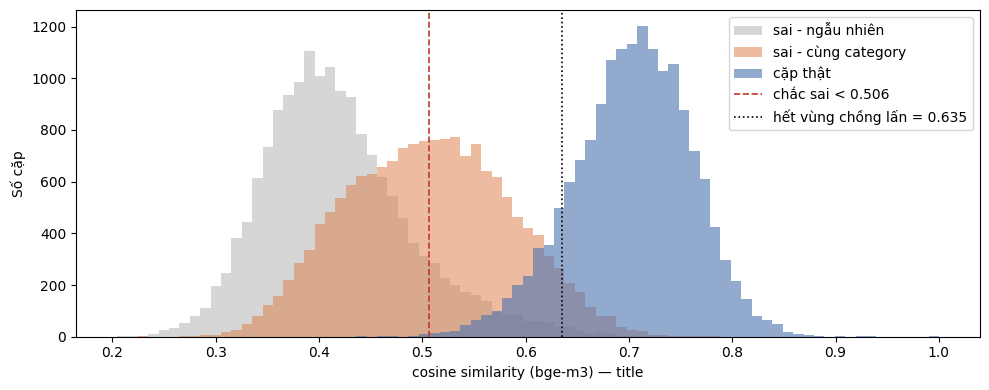

In [19]:
# --- 5.2 Mốc nền từ cặp ghép sai ---
NEG_Q_HARD = 0.50   # tệ hơn một nửa số cặp ghép sai -> gần như chắc sai
NEG_Q_GREY = 0.95   # từ trung vị đến p95 cặp sai: vùng chồng lấn, similarity không tự quyết được
rng = np.random.default_rng(42)
n = len(work)

def derange(pos):
    """Hoán vị pos sao cho không phần tử nào đứng yên (không ghép sản phẩm với chính nó)."""
    p = rng.permutation(pos)
    fixed = p == pos
    p[fixed] = np.roll(p, 1)[fixed]
    return p

perm_rand = derange(np.arange(n))
perm_same = np.arange(n)
cats = work["category"].to_numpy()
for c in np.unique(cats):
    pos = np.flatnonzero(cats == c)
    if len(pos) > 1:
        perm_same[pos] = derange(pos)

work["sim_rand"] = (zh_emb * vi_emb[perm_rand]).sum(axis=1)
work["sim_samecat"] = (zh_emb * vi_emb[perm_same]).sum(axis=1)

def auc(pos_scores, neg_scores):
    s = pd.Series(np.concatenate([pos_scores, neg_scores])).rank().to_numpy()
    n1, n2 = len(pos_scores), len(neg_scores)
    return float((s[:n1].sum() - n1 * (n1 + 1) / 2) / (n1 * n2))

pcts = [.01, .05, .25, .5, .75, .95, .99]
display(pd.DataFrame({
    "cặp thật": work["sim_score"].describe(percentiles=pcts),
    "sai - cùng category": work["sim_samecat"].describe(percentiles=pcts),
    "sai - ngẫu nhiên": work["sim_rand"].describe(percentiles=pcts),
}).round(3))

TITLE_AUC = auc(work["sim_score"].to_numpy(), work["sim_samecat"].to_numpy())
print(f"AUC thật vs sai-cùng-category: {TITLE_AUC:.4f}")
print(f"AUC thật vs sai-ngẫu nhiên:    {auc(work['sim_score'].to_numpy(), work['sim_rand'].to_numpy()):.4f}")

SIM_THRESHOLD = float(work["sim_samecat"].quantile(NEG_Q_HARD))
GREY_THRESHOLD = float(work["sim_samecat"].quantile(NEG_Q_GREY))
hard = work["sim_score"] < SIM_THRESHOLD
grey = (work["sim_score"] >= SIM_THRESHOLD) & (work["sim_score"] < GREY_THRESHOLD)
clear = work["sim_score"] >= GREY_THRESHOLD
print(f"\nChắc sai   (< trung vị cặp sai = {SIM_THRESHOLD:.3f}): {int(hard.sum()):>6,} cặp ({100*hard.mean():.2f}%)")
print(f"Chồng lấn  ([{SIM_THRESHOLD:.3f}, {GREY_THRESHOLD:.3f}) = p50-p95 cặp sai): {int(grey.sum()):>6,} cặp ({100*grey.mean():.2f}%)"
      "  <- similarity không tự quyết được")
print(f"Tách rõ    (>= p95 cặp sai = {GREY_THRESHOLD:.3f}): {int(clear.sum()):>6,} cặp ({100*clear.mean():.2f}%)")
print(f"(Đối chiếu: ngưỡng 0.5 cũ bắt {int((work['sim_score'] < 0.5).sum())} cặp, xấp xỉ mốc 'chắc sai'.)")

print("\n--- Các cặp 'chắc sai' ---")
display(work[hard].sort_values("sim_score")[["category", ZH_COL, VI_COL, "sim_score"]])

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(float(min(work["sim_rand"].min(), work["sim_score"].min())), 1.0, 80)
ax.hist(work["sim_rand"], bins=bins, alpha=.4, label="sai - ngẫu nhiên", color="#999999")
ax.hist(work["sim_samecat"], bins=bins, alpha=.55, label="sai - cùng category", color="#DD8452")
ax.hist(work["sim_score"], bins=bins, alpha=.6, label="cặp thật", color="#4C72B0")
ax.axvline(SIM_THRESHOLD, color="#C0392B", ls="--", lw=1.2, label=f"chắc sai < {SIM_THRESHOLD:.3f}")
ax.axvline(GREY_THRESHOLD, color="k", ls=":", lw=1.2, label=f"hết vùng chồng lấn = {GREY_THRESHOLD:.3f}")
ax.set_xlabel("cosine similarity (bge-m3) — title")
ax.set_ylabel("Số cặp")
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 Xếp hạng trong từng category

Mỗi category có mặt bằng điểm khác nhau, nên dùng **mốc "chắc sai" riêng từng category** (trung vị cặp sai cùng category đó)
và lấy **3% cặp thấp nhất mỗi category** ra file để đọc tay (xuất ở mục 7, có sẵn cột ghi chú).

In [20]:
# --- 5.3 Xếp hạng trong từng category ---
REVIEW_PCT = 0.03

work["rank_pct_in_cat"] = work.groupby("category")["sim_score"].rank(pct=True)
cat_thr = work.groupby("category")["sim_samecat"].quantile(NEG_Q_HARD)
work["below_cat_threshold"] = work["sim_score"] < work["category"].map(cat_thr)

per_cat = work.groupby("category").agg(
    so_cap=("sim_score", "size"),
    sim_tb=("sim_score", "mean"),
    sim_p05=("sim_score", lambda s: s.quantile(.05)),
    sai_cung_cat_tb=("sim_samecat", "mean"),
    chac_sai=("below_cat_threshold", "sum"),
)
per_cat["nguong_chac_sai"] = cat_thr
per_cat["chac_sai_%"] = 100 * per_cat["chac_sai"] / per_cat["so_cap"]
display(per_cat.sort_values("sim_tb").round(3))

# Lấy ceil(3% x số cặp) cặp thấp nhất mỗi category, tối thiểu 1 (category nhỏ không bị bỏ sót vì làm tròn)
rank_in_cat = work.groupby("category")["sim_score"].rank(method="first")
k_in_cat = work.groupby("category")["sim_score"].transform(lambda s: max(1, int(np.ceil(REVIEW_PCT * len(s)))))
review = work[rank_in_cat <= k_in_cat].sort_values(["category", "sim_score"])
print(f"\n{len(review):,} cặp ({100*REVIEW_PCT:.0f}% thấp nhất mỗi category) cần đọc tay. 3 cặp thấp nhất mỗi category:")
display(review.groupby("category").head(3)[["category", ZH_COL, VI_COL, "sim_score"]])

,so_cap,sim_tb,sim_p05,sai_cung_cat_tb,chac_sai,nguong_chac_sai,chac_sai_%
category,,,,,,,
food,1421,0.630,0.544,0.465,2,0.466,0.141
beauty,1318,0.662,0.566,0.486,1,0.487,0.076
fashion,1351,0.679,0.609,0.517,1,0.526,0.074
home,2493,0.707,0.631,0.498,0,0.486,0.000
mother_baby,2496,0.707,0.629,0.484,0,0.466,0.000
shoes,2311,0.708,0.629,0.539,1,0.536,0.043
bags,2878,0.725,0.642,0.548,1,0.546,0.035
auto,971,0.731,0.633,0.480,0,0.472,0.000
electronics,1109,0.757,0.679,0.486,0,0.470,0.000



495 cặp (3% thấp nhất mỗi category) cần đọc tay. 3 cặp thấp nhất mỗi category:


,category,title_zh,title_vi,sim_score
402,auto,龙旗车载手机支架汽车导航车用专用仪表台无痕防滑垫支架一件代发,Rồng Cờ Ô Tô Di Động Điện Thoại Ô Tô Ô Tô Đặc Biệt Bảng Điều Khiển Liền Mạch...,0.539515
253,auto,包邮大灯翻新修复液车灯镀晶液发黄免打磨雾化清洁剂抛光套装代发,"Dung dịch sửa chữa đèn pha Topbit, dung dịch phủ pha lê đèn xe hơi, bộ vệ si...",0.542455
105,auto,跨境新款美国国旗老鹰汽车内饰后视镜挂件异形钥匙链装饰挂件吊坠,Mặt dây chuyền trang trí chìa khóa hình đặc biệt,0.555819
1360,bags,亚马逊爆款双肩包 跨境贴标小单快反 48小时发货大容量电脑包,"Túi du lịch thông thường phổ biến dành cho nữ, túi đựng máy tính dành cho si...",0.521679
4332,bags,【柜级品质】西太后新款鳄鱼纹腋下包压纹牛皮斜跨通勤链条单肩包,[Chất lượng cấp tủ] Túi đeo chéo họa tiết cá sấu mới của Hoàng hậu phương Tâ...,0.552223
2376,bags,香港MackJhosel PU小众复古帆布法棍腋下包女秋夏新款单肩包,Túi Đeo Vai Nữ Mẫu Mới mùa thu hè,0.558736
3396,beauty,一枝春玻尿酸补水面膜美白保湿提亮肤色紧致滋润贴片面膜厂家批发,"Yizhichun Hyaluronic Acid Hydrating Mask Làm trắng, dưỡng ẩm, làm sáng da, l...",0.474327
5090,beauty,碧素堂蜗牛面膜补水保湿美白滋润嫩肤面膜盈润养护厂家,"Bisutang Snail Mask Hydrating, Dưỡng ẩm, Làm trắng, Dưỡng ẩm và Trẻ hóa Mặt ...",0.502104
5119,beauty,施逅微晶胶原额头贴川字纹抬头纹抗皱紧致淡纹填充贴面膜正品批发,Mặt nạ làm đầy nếp nhăn làm săn chắc da trắng chống nhăn mặt nạ làm đầy nếp ...,0.505023
3967,electronics,影巨人气传导蓝牙耳机不入耳空气传导无线运动挂耳式跨境私模,Tai nghe Bluetooth dẫn không khí của người khổng lồ bóng tối,0.573132


### 5.4 Chữ Hán còn sót trong cột tiếng Việt

Similarity **không** bắt được lỗi này, thậm chí chấm điểm cao hơn (vì 2 bên giống nhau từng ký tự).
Regex viết bằng ký tự thật `"[一-鿿]"` (chuỗi thường, không phải `r"..."`): pandas bản mới dùng regex của
Arrow, không hiểu cú pháp `\u` trong chuỗi raw.

In [21]:
# --- 5.4 Chữ Hán còn sót trong cột tiếng Việt ---
CJK = "[一-鿿]"   # chuỗi thường: Python đổi \u thành ký tự thật trước khi đưa cho regex

for c in [c for c in ["title_vi", "description_vi"] if c in df.columns]:
    df[f"cjk_in_{c}"] = df[c].fillna("").astype(str).str.contains(CJK, regex=True)
    k = int(df[f"cjk_in_{c}"].sum())
    print(f"{c:<16} còn chữ Hán: {k:>6,} dòng ({100*k/len(df):.2f}%)")

cjk_ratio = df[VI_COL].fillna("").astype(str).map(lambda s: len(re.findall(CJK, s)) / max(len(s), 1))
print(f"{VI_COL} gần như chưa dịch (>50% ký tự là chữ Hán): {int((cjk_ratio > .5).sum())} dòng")

work["cjk_in_title_vi"] = df.loc[work.index, "cjk_in_title_vi"].to_numpy() if "cjk_in_title_vi" in df.columns else False
if work["cjk_in_title_vi"].any():
    print(f"\nSimilarity TB: dòng còn chữ Hán = {work.loc[work['cjk_in_title_vi'], 'sim_score'].mean():.3f} "
          f"| dòng sạch = {work.loc[~work['cjk_in_title_vi'], 'sim_score'].mean():.3f}  (điểm cao không có nghĩa là dịch tốt)")
    display(work[work["cjk_in_title_vi"]].sort_values("sim_score", ascending=False)
            [["category", ZH_COL, VI_COL, "sim_score", "rank_pct_in_cat"]])

if "cjk_in_description_vi" in df.columns and "category" in df.columns:
    print("\ndescription_vi còn chữ Hán, theo category:")
    display(df.groupby("category")["cjk_in_description_vi"].agg(so_dong="sum", ty_le="mean")
            .assign(ty_le=lambda t: (100 * t["ty_le"]).round(2)).sort_values("so_dong", ascending=False))

title_vi         còn chữ Hán:      7 dòng (0.04%)
description_vi   còn chữ Hán:  2,098 dòng (12.83%)
title_vi gần như chưa dịch (>50% ký tự là chữ Hán): 2 dòng

Similarity TB: dòng còn chữ Hán = 0.825 | dòng sạch = 0.702  (điểm cao không có nghĩa là dịch tốt)


,category,title_zh,title_vi,sim_score,rank_pct_in_cat
2604,bags,2026新款Polèn真皮马鞍包女高级感通勤单肩斜挎包小众设计感腋下,2026新款Polèn真皮马鞍包女高级感通勤单肩斜挎包小众设计感腋下,1.000000,1.000000
5321,beauty,HEATÔR夕碧泉水杨酸栀子花控油洁面乳清洁面部洗面奶厂家代发,HEATÔR夕碧泉水杨酸栀子花控油洁面乳清洁面部洗面奶厂家代发,1.000000,1.000000
6790,food,Gaba Dahongpao tea Габа чай 嘎巴大红袍乌龙茶,Trà Gaba Dahongpao Trà Gaba 嘎巴大红袍乌龙茶,0.923649,0.999296
14637,mother_baby,50个装新生一次性储奶瓶婴儿奶瓶NICU奶瓶送医院早产儿无菌送奶瓶,"50 bình trữ sữa dùng một lần cho trẻ sơ sinh, bình sữa, bình sữa NICU, bình ...",0.777255,0.943910
7993,home,出口日本丨100%纯棉全棉春秋四件套 床上床品被套床单床笠款床品,Xuất khẩu sang Nhật Bản 丨 Bộ chăn ga gối bốn mảnh 100% cotton mùa xuân và mù...,0.751408,0.845568
9295,fashion,【一折专区】奥莱精选丨重磅丨男装T恤丨短袖夏季丨美式潮牌,[Giảm giá 10%] Lựa chọn của Ole 丨 Áo phông nam hạng nặng 丨 Áo phông nam ngắn...,0.733920,0.897113
6297,fashion,镂空提花纯欲针织吊带白色连衣裙2026夏季气质新款收腰背心短裙子,"Váy liền thân dệt kim jacquard镂空 màu trắng dây spaghetti, kiểu dáng ôm eo, t...",0.588337,0.015544



description_vi còn chữ Hán, theo category:


,so_dong,ty_le
category,,
home,400,16.04
beauty,312,23.67
mother_baby,286,11.46
bags,273,9.49
food,256,18.02
shoes,174,7.53
electronics,164,14.79
auto,157,16.17
fashion,76,5.63


### 5.5 Description: so từng cặp thuộc tính

`description_zh` / `description_vi` được ghép lúc crawl theo **cùng thứ tự thuộc tính**, dạng
`Tên: giá trị; Tên: giá trị; ...`, nên tách theo `"; "` rồi ghép cặp theo vị trí. Chỉ dùng dòng có số thuộc tính
2 bên bằng nhau (dòng lệch là do dấu `；` trong giá trị tiếng Trung bị dịch thành `"; "`).

- So **tên thuộc tính** (bắt lỗi dịch tên lặp lại trên hàng nghìn sản phẩm, vd `皮质特征` → "Đặc điểm vỏ não").
- So **giá trị** (mốc nền: đổi giá trị với sản phẩm khác **cùng tên thuộc tính**).
- Chỉ embed mỗi chuỗi **duy nhất** một lần (rất nhiều giá trị lặp: `否`, `PVC`...).
- Thêm 2 cờ regex mà similarity không bắt được: **lỗi đánh số** (`Khác1`, `Là2`, `Không.1`) và **chữ Hán còn sót**.

In [22]:
# --- 5.5 Description theo từng cặp thuộc tính ---
def split_desc(text):
    out = []
    for seg in str(text or "").split("; "):
        if seg.strip():
            name, sep, val = seg.partition(": ")
            out.append((name.strip(), val.strip()) if sep else ("", seg.strip()))
    return out

seg_zh = df["description_zh"].map(split_desc)
seg_vi = df["description_vi"].map(split_desc)
aligned = seg_zh.map(len) == seg_vi.map(len)
print(f"Dòng ghép cặp được: {int(aligned.sum()):,} / {len(df):,} ({100*aligned.mean():.2f}%)")

rows = []
for i in df.index[aligned]:
    for (nz, vz), (nv, vv) in zip(seg_zh[i], seg_vi[i]):
        rows.append((i, nz, vz, nv, vv))
attr = pd.DataFrame(rows, columns=["row", "name_zh", "val_zh", "name_vi", "val_vi"])
attr["product_id"] = df.loc[attr["row"], "product_id"].to_numpy() if "product_id" in df.columns else attr["row"]
attr["category"] = df.loc[attr["row"], "category"].to_numpy() if "category" in df.columns else "all"
print(f"Tổng cặp thuộc tính: {len(attr):,}")

def rowdot(A, ia, B, ib, chunk=50_000):
    """Tích vô hướng A[ia[k]] . B[ib[k]], chia khối để không tạo mảng khổng lồ trong RAM."""
    out = np.empty(len(ia), dtype=np.float32)
    for s in range(0, len(ia), chunk):
        out[s:s + chunk] = (A[ia[s:s + chunk]] * B[ib[s:s + chunk]]).sum(axis=1)
    return out

def embed_unique(texts, batch_size):
    idx = pd.Index(pd.unique(pd.Series(texts)))
    return idx, encode_np(list(idx), batch_size=batch_size)

# (a) Giá trị thuộc tính
iz, Ez = embed_unique(attr["val_zh"], batch_size=64)
iv, Ev = embed_unique(attr["val_vi"], batch_size=64)
attr["sim_val"] = rowdot(Ez, iz.get_indexer(attr["val_zh"]), Ev, iv.get_indexer(attr["val_vi"]))

# Mốc nền: ghép giá trị Trung với giá trị Việt của sản phẩm khác CÙNG tên thuộc tính,
# chỉ tính những cặp mà giá trị Trung thật sự khác nhau (tránh "否" ghép với "否").
partner = np.arange(len(attr))
for _, pos in attr.groupby("name_zh").indices.items():
    if len(pos) > 1:
        partner[pos] = rng.permutation(pos)
vz = attr["val_zh"].to_numpy()
diff = vz[partner] != vz
neg_val = rowdot(Ez, iz.get_indexer(vz[diff]), Ev, iv.get_indexer(attr["val_vi"].to_numpy()[partner][diff]))
VAL_THRESHOLD = float(np.quantile(neg_val, NEG_Q_HARD))
VAL_AUC = auc(attr["sim_val"].to_numpy(), neg_val)
attr["below_threshold"] = attr["sim_val"] < VAL_THRESHOLD

# (b) Tên thuộc tính: mốc nền = tên Việt của một tên Trung khác
names = attr.groupby(["name_zh", "name_vi"]).size().rename("so_lan").reset_index()
inz, Enz = embed_unique(names["name_zh"], batch_size=128)
inv, Env = embed_unique(names["name_vi"], batch_size=128)
names["sim_name"] = rowdot(Enz, inz.get_indexer(names["name_zh"]), Env, inv.get_indexer(names["name_vi"]))
np_perm = derange(np.arange(len(names)))
diff_n = names["name_zh"].to_numpy()[np_perm] != names["name_zh"].to_numpy()
neg_name = rowdot(Enz, inz.get_indexer(names["name_zh"][diff_n]),
                  Env, inv.get_indexer(names["name_vi"].to_numpy()[np_perm][diff_n]))
NAME_THRESHOLD = float(np.quantile(neg_name, NEG_Q_HARD))

# (c) Cờ regex: lỗi đánh số của 1688 và chữ Hán còn sót
attr["numbering_artifact"] = attr["val_vi"].str.contains(r"(?:Không|Có|Là|Khác)\.?\d+\s*$", regex=True)
attr["cjk_in_vi"] = (attr["val_vi"].str.contains(CJK, regex=True) | attr["name_vi"].str.contains(CJK, regex=True))

print(f"\n--- Giá trị thuộc tính ({len(attr):,} cặp, {len(iz):,} + {len(iv):,} chuỗi duy nhất) ---")
display(pd.DataFrame({"cặp thật": attr["sim_val"].describe(percentiles=pcts),
                      "sai - cùng tên thuộc tính": pd.Series(neg_val).describe(percentiles=pcts)}).round(3))
print(f"AUC = {VAL_AUC:.4f} | mốc chắc sai (trung vị cặp sai) = {VAL_THRESHOLD:.3f} | "
      f"cặp dưới mốc: {int(attr['below_threshold'].sum()):,} ({100*attr['below_threshold'].mean():.2f}%)")
if VAL_AUC < 0.9:
    print("⚠️ AUC < 0.9: với chuỗi ngắn (1-3 từ), bge-m3 phân biệt đúng/sai kém — nhiều bản dịch đúng vẫn điểm thấp\n"
          "   (vd 广州 -> 'Quảng Châu'). Danh sách dưới mốc chỉ để đọc tay, KHÔNG dùng để xoá tự động.\n"
          "   Tín hiệu đáng tin ở mức thuộc tính là 2 cờ regex bên dưới.")
print(f"Lỗi đánh số (Khác1/Là2/Không.1): {int(attr['numbering_artifact'].sum()):,} cặp "
      f"({100*attr['numbering_artifact'].mean():.2f}%) — sim TB {attr.loc[attr['numbering_artifact'], 'sim_val'].mean():.3f}, "
      f"trong đó dưới mốc chắc sai: {int((attr['numbering_artifact'] & attr['below_threshold']).sum()):,}")
print(f"Chữ Hán còn sót: {int(attr['cjk_in_vi'].sum()):,} cặp ({100*attr['cjk_in_vi'].mean():.2f}%) — "
      f"sim TB {attr.loc[attr['cjk_in_vi'], 'sim_val'].mean():.3f}")

print("\nTỉ lệ (%) theo category: dưới mốc chắc sai / lỗi đánh số / chữ Hán còn sót:")
display((attr.groupby("category")[["below_threshold", "numbering_artifact", "cjk_in_vi"]].mean() * 100)
        .round(2).sort_values("below_threshold", ascending=False))

print("\nCặp giá trị dưới mốc, lặp lại nhiều nhất (ứng viên lỗi dịch có hệ thống — cần đọc tay xác nhận):")
low_vals = (attr[attr["below_threshold"]].groupby(["name_zh", "val_zh", "val_vi"])
            .agg(so_lan=("sim_val", "size"), sim=("sim_val", "first"))
            .sort_values("so_lan", ascending=False).reset_index())
display(low_vals.head(20))

print(f"\n--- Tên thuộc tính ({len(names):,} cặp tên khác nhau) | mốc chắc sai = {NAME_THRESHOLD:.3f} ---")
low_names = names[names["sim_name"] < NAME_THRESHOLD].sort_values("so_lan", ascending=False)
print(f"{len(low_names):,} cặp tên dưới mốc, xuất hiện tổng {int(low_names['so_lan'].sum()):,} lần. "
      "20 cặp gặp nhiều nhất (tên lặp trên nhiều sản phẩm nên sửa 1 lần được nhiều dòng):")
display(low_names.head(20).round(3))

Dòng ghép cặp được: 16,276 / 16,348 (99.56%)
Tổng cặp thuộc tính: 405,190

--- Giá trị thuộc tính (405,190 cặp, 56,757 + 70,238 chuỗi duy nhất) ---


,cặp thật,sai - cùng tên thuộc tính
count,405190.000,288953.000
mean,0.714,0.512
std,0.171,0.138
min,0.148,0.104
1%,0.363,0.258
5%,0.460,0.321
25%,0.573,0.414
50%,0.707,0.487
75%,0.846,0.591
95%,1.000,0.779


AUC = 0.8191 | mốc chắc sai (trung vị cặp sai) = 0.487 | cặp dưới mốc: 34,432 (8.50%)
⚠️ AUC < 0.9: với chuỗi ngắn (1-3 từ), bge-m3 phân biệt đúng/sai kém — nhiều bản dịch đúng vẫn điểm thấp
   (vd 广州 -> 'Quảng Châu'). Danh sách dưới mốc chỉ để đọc tay, KHÔNG dùng để xoá tự động.
   Tín hiệu đáng tin ở mức thuộc tính là 2 cờ regex bên dưới.
Lỗi đánh số (Khác1/Là2/Không.1): 36,370 cặp (8.98%) — sim TB 0.576, trong đó dưới mốc chắc sai: 2,666
Chữ Hán còn sót: 4,971 cặp (1.23%) — sim TB 0.993

Tỉ lệ (%) theo category: dưới mốc chắc sai / lỗi đánh số / chữ Hán còn sót:


,below_threshold,numbering_artifact,cjk_in_vi
category,,,
food,13.90,9.24,1.82
mother_baby,9.82,10.28,0.74
home,9.06,12.67,2.30
shoes,9.04,8.32,0.33
fashion,8.43,8.69,0.41
electronics,7.77,8.18,1.57
beauty,6.95,12.00,3.25
auto,4.94,12.71,1.96
bags,4.91,2.05,1.07



Cặp giá trị dưới mốc, lặp lại nhiều nhất (ứng viên lỗi dịch có hệ thống — cần đọc tay xác nhận):


,name_zh,val_zh,val_vi,so_lan,sim
0,鞋底材质,橡胶,Cao su,921,0.430663
1,产地,浙江,Chiết Giang,792,0.468751
2,有可授权的自有品牌,是,Là,639,0.480451
3,适用运动,通用,Đa năng,611,0.471541
4,是否跨境出口专供货源,是,Là,570,0.480451
5,主面料成分,棉,Bông2,502,0.391578
6,面料名称,棉,Bông1,495,0.416534
7,产地,河南,Hà Nam,473,0.396743
8,主面料成分,棉,Bông,459,0.439529
9,原产地,福建,Phúc Kiến,410,0.386554



--- Tên thuộc tính (4,151 cặp tên khác nhau) | mốc chắc sai = 0.424 ---
31 cặp tên dưới mốc, xuất hiện tổng 1,300 lần. 20 cặp gặp nhiều nhất (tên lặp trên nhiều sản phẩm nên sửa 1 lần được nhiều dòng):


,name_zh,name_vi,so_lan,sim_name
2501,毛重,Trọng lượng tịnh,876,0.417
4029,领标,Nhãn,377,0.303
4030,领标,Nhãn chì,13,0.358
1228,声道,Kênh,6,0.370
2860,礼服摆型,Váy xòe,2,0.403
1371,奶嘴,Núm ti,1,0.391
1392,奶瓶是否带柄,Thông số kỹ thuật,1,0.402
1544,属性三,Mẫu mã,1,0.413
1495,小狗小熊收纳箱,Mẫu mã,1,0.387
1662,张家界特产,Mẫu mã,1,0.344


## 6. Kiểm tra căn chỉnh (heuristic token-ratio)

Bổ sung cho similarity: heuristic tỷ lệ độ dài token để bắt các cặp "lệch căn chỉnh"
do bản dịch bị thiếu/thừa/trộn dòng.


In [23]:
# --- Heuristic phát hiện cặp câu nghi lệch căn chỉnh ---
# KHÔNG dùng \W để phát hiện "toàn ký tự đặc biệt" cho tiếng Trung:
# Python coi chữ Hán là \W -> regex sẽ khớp ~62% dữ liệu (sai).
# Dùng lớp ASCII tường minh: chỉ số + dấu câu ASCII + khoảng trắng.
SPECIAL_ONLY = r"^[\s\d!-/:-@\[-`{-~]*$"   # số & dấu câu ASCII, KHÔNG gồm chữ Hán
ASCII_ONLY = r"^[\x00-\x7F]+$"             # không có ký tự ngoài ASCII (zh phải có Hán tự)

def build_flags(frame):
    f = pd.DataFrame(index=frame.index)
    f["zh_len"] = len_zh
    f["vi_len"] = len_vi
    f["ratio_tok"] = ratio_tok
    f["ratio_char"] = ratio_char
    f["flag_ratio"] = (ratio_tok > RATIO_HI) | (ratio_tok < RATIO_LO)
    f["flag_short"] = (len_zh < 3) | (len_vi < 3)
    f["flag_special"] = (
        frame[ZH_COL].fillna("").astype(str).str.fullmatch(SPECIAL_ONLY, na=False)
        | frame[VI_COL].fillna("").astype(str).str.fullmatch(SPECIAL_ONLY, na=False)
    )
    f["flag_ascii_zh"] = frame[ZH_COL].fillna("").astype(str).str.fullmatch(ASCII_ONLY, na=False)
    f["flag_dup"] = frame[TEXT_COLS].duplicated(keep=False)
    f["is_suspect"] = f[["flag_ratio", "flag_short", "flag_special", "flag_ascii_zh"]].any(axis=1)
    return f

flags = build_flags(df)
print("--- Số câu theo từng cờ nghi vấn ---")
for c in ["flag_ratio", "flag_short", "flag_special", "flag_ascii_zh", "flag_dup", "is_suspect"]:
    print(f"{c:<16} {int(flags[c].sum()):>7}  ({100*flags[c].mean():.2f}%)")

suspect = df.loc[flags["is_suspect"]].copy()
suspect["_reason"] = flags.loc[flags["is_suspect"],
    ["flag_ratio", "flag_short", "flag_special", "flag_ascii_zh"]].apply(
    lambda r: ",".join(r.index[r.values].str.replace("flag_", "")), axis=1)
suspect["_ratio_tok"] = flags.loc[flags["is_suspect"], "ratio_tok"].round(2)

print(f"\n--- 20 mẫu nghi vấn / tổng {len(suspect)} ---")
display(suspect[[ZH_COL, VI_COL, "_reason", "_ratio_tok"]].head(20))


--- Số câu theo từng cờ nghi vấn ---
flag_ratio            29  (0.18%)
flag_short             0  (0.00%)
flag_special           0  (0.00%)
flag_ascii_zh          0  (0.00%)
flag_dup             402  (2.46%)
is_suspect            29  (0.18%)

--- 20 mẫu nghi vấn / tổng 29 ---


,title_zh,title_vi,_reason,_ratio_tok
61,车载垃圾袋粘贴自立式收纳袋汽车内用桶必用品车上好物备实用大全,Túi đựng rác trên ô tô,ratio,0.20
227,汽车座椅缝隙塞条车内装饰用品大全车载夹缝防漏填补条收纳储物盒,Khe hở ghế ô tô,ratio,0.17
303,汽车座椅缝隙塞条车载好物边缝防漏条座位夹缝塞防掉车内装饰用品,Khe hở ghế ô tô,ratio,0.17
310,跨境车品新款汽车座椅缝隙塞条夹缝填补边缝防漏储物车载内饰用品,Sản phẩm ô tô xuyên biên giới,ratio,0.23
414,临时停车电话号码牌汽车移车挪车牌停车号码牌磁吸夜光车载电话牌,Biển số điện thoại đỗ xe tạm thời,ratio,0.27
475,跨境4K行车记录仪高清夜视前后双录手机互联倒车影像车载记录器,Ghi hình lái xe 4K xuyên biên giới,ratio,0.27
1002,奥迪专用行车记录仪A4L/A6L/Q5L/A7L/A3/Q3/TT/Q4/Q6手机WiFi互联,Audi chuyên dụng lái xe ghi A4L/A6L/Q5L/A7L/A3/Q3/TT/Q4/Q6 điện thoại di độn...,ratio,0.30
1287,奥迪A3/A4/A5/A6L/A8/Q2/Q7/Q5/RS7/S5原厂专车专用4K行车记录仪,Audi A3/A4/A5/A6L/A8/Q2/Q7/Q5/RS7/S5 chuyên dụng 4K lái xe,ratio,0.15
1385,轻便网架户外包防泼水运动登山双肩包30L徒步背包,Ba lô đi bộ đường dài 30L,ratio,0.29
2376,香港MackJhosel PU小众复古帆布法棍腋下包女秋夏新款单肩包,Túi Đeo Vai Nữ Mẫu Mới mùa thu hè,ratio,0.27


## 7. Xuất báo cáo & kết luận

In [24]:
# --- Bảng tổng hợp chỉ số chính ---
summary = pd.DataFrame([{
    "rows": len(df),
    "cols": df.shape[1],
    "null_%_max": round(null_df["null_%"].max(), 2),
    "empty_%_max": round(null_df["empty_%"].max(), 2),
    "dup_pair_%": round(100 * dup_pair / len(df), 2),
    "dup_zh_%": round(100 * dup_zh / len(df), 2),
    "dup_vi_%": round(100 * dup_vi / len(df), 2),
    "avg_len_zh": round(len_zh.mean(), 1),
    "avg_len_vi": round(len_vi.mean(), 1),
    "avg_tok_zh": round(tok_zh.mean(), 1),
    "avg_tok_vi": round(tok_vi.mean(), 1),
    "ratio_tok_median": round(ratio_tok.median(), 2),
    "ratio_outliers_%": round(100 * n_tok_out / len(df), 2),
    "suspect_%": round(100 * flags["is_suspect"].mean(), 2),
    "title_pairs_scored": len(work),
    "title_sim_mean": round(work["sim_score"].mean(), 3),
    "title_threshold_hard_p50_neg": round(SIM_THRESHOLD, 3),
    "title_threshold_grey_p95_neg": round(GREY_THRESHOLD, 3),
    "title_auc_vs_samecat_neg": round(TITLE_AUC, 4),
    "title_hard_wrong_n": int((work["sim_score"] < SIM_THRESHOLD).sum()),
    "title_grey_zone_%": round(100 * ((work["sim_score"] >= SIM_THRESHOLD) & (work["sim_score"] < GREY_THRESHOLD)).mean(), 2),
    "title_vi_with_chinese": int(df["cjk_in_title_vi"].sum()),
    "description_vi_with_chinese_%": round(100 * df["cjk_in_description_vi"].mean(), 2),
    "attr_pairs": len(attr),
    "attr_threshold_hard_p50_neg": round(VAL_THRESHOLD, 3),
    "attr_auc_vs_samename_neg": round(VAL_AUC, 4),
    "attr_below_threshold_%": round(100 * attr["below_threshold"].mean(), 2),
    "attr_numbering_artifact_%": round(100 * attr["numbering_artifact"].mean(), 2),
    "attr_vi_with_chinese_%": round(100 * attr["cjk_in_vi"].mean(), 2),
}]).T.rename(columns={0: "value"})

print("=" * 46)
print("BẢNG TỔNG HỢP EDA")
print("=" * 46)
display(summary)

# --- Lưu kết quả ra CSV ---
OUT_SUSPECT = "eda_suspect_pairs.csv"           # heuristic token-ratio (mục 6)
OUT_SUMMARY = "eda_summary.csv"
OUT_REVIEW = "eda_title_review_by_category.csv"  # 3% thấp nhất mỗi category, có cột để ghi nhận xét
OUT_CJK = "eda_chinese_left_in_vi.csv"
OUT_ATTR = "eda_attr_below_threshold.csv"
OUT_ATTR_NAMES = "eda_attr_names_low_sim.csv"

# Loại cột nested (attributes_zh/vi) trước khi ghi CSV: chúng là list<struct>,
# khi to_csv sẽ bị repr thành nhiều dòng -> làm hỏng cấu trúc file.
def drop_nested(frame):
    keep = [c for c in frame.columns if not frame[c].map(type).isin([list, dict]).any()]
    return frame[keep]

try:
    out = drop_nested(suspect).copy()
    out["reason"] = suspect["_reason"]
    out["ratio_tok"] = suspect["_ratio_tok"]
    out["sim_score"] = suspect["sim_score"].round(3)
    out.to_csv(OUT_SUSPECT, index=False, encoding="utf-8-sig")

    rv = work.loc[review.index, [c for c in ["product_id", "category", ZH_COL, VI_COL, "sim_score", "rank_pct_in_cat",
                                             "below_cat_threshold", "cjk_in_title_vi"] if c in work.columns]].copy()
    rv["sim_score"] = rv["sim_score"].round(3)
    rv["rank_pct_in_cat"] = rv["rank_pct_in_cat"].round(3)
    rv["danh_gia"] = ""   # đọc tay: dung / sai / nghi
    rv["ghi_chu"] = ""
    rv.to_csv(OUT_REVIEW, index=False, encoding="utf-8-sig")

    cjk_cols = [c for c in ["product_id", "category", "title_zh", "title_vi", "description_zh", "description_vi",
                            "cjk_in_title_vi", "cjk_in_description_vi", "sim_score"] if c in df.columns]
    df.loc[df["cjk_in_title_vi"] | df["cjk_in_description_vi"], cjk_cols].to_csv(OUT_CJK, index=False, encoding="utf-8-sig")

    attr[attr["below_threshold"]].drop(columns=["row"]).sort_values(["category", "sim_val"]) \
        .round({"sim_val": 3}).to_csv(OUT_ATTR, index=False, encoding="utf-8-sig")
    low_names.round(3).to_csv(OUT_ATTR_NAMES, index=False, encoding="utf-8-sig")

    summary.to_csv(OUT_SUMMARY, encoding="utf-8-sig")
    print(f"\n✅ {len(out):,} mẫu nghi vấn heuristic -> {OUT_SUSPECT}")
    print(f"✅ {len(rv):,} cặp title cần đọc tay (3% thấp nhất mỗi category) -> {OUT_REVIEW}")
    print(f"✅ {int((df['cjk_in_title_vi'] | df['cjk_in_description_vi']).sum()):,} dòng còn chữ Hán -> {OUT_CJK}")
    print(f"✅ {int(attr['below_threshold'].sum()):,} cặp thuộc tính dưới ngưỡng -> {OUT_ATTR}")
    print(f"✅ {len(low_names):,} cặp tên thuộc tính dưới ngưỡng -> {OUT_ATTR_NAMES}")
    print(f"✅ Bảng tổng hợp -> {OUT_SUMMARY}")
except Exception as e:
    print("Lỗi xuất CSV:", e)

# --- Kết luận nhanh ---
print("\n--- NHẬN XÉT NHANH ---")
print(f"• Dữ liệu sạch về null: chỉ {int((null_df['null_%'] > 0).sum())} cột có null.")
print(f"• Trùng lặp cặp câu ở mức thấp ({100*dup_pair/len(df):.2f}%), nhưng {ZH_COL} trùng "
      f"{100*dup_zh/len(df):.2f}% -> nhiều sản phẩm khác nhau dùng chung tiêu đề.")
print(f"• Tỷ lệ độ dài zh/vi ổn định (median {ratio_tok.median():.2f} token vi / ký tự zh).")
print(f"• Title: AUC {TITLE_AUC:.3f} (thật vs sai cùng category). {int((work['sim_score'] < SIM_THRESHOLD).sum())} cặp "
      f"'chắc sai' (< {SIM_THRESHOLD:.3f}); {100*((work['sim_score'] >= SIM_THRESHOLD) & (work['sim_score'] < GREY_THRESHOLD)).mean():.1f}% "
      f"nằm trong vùng chồng lấn -> similarity chỉ bắt lỗi thô, lỗi chi tiết (đơn vị, mất chữ) phải đọc tay ({OUT_REVIEW}).")
print(f"• Description (theo thuộc tính): AUC {VAL_AUC:.3f}, {100*attr['below_threshold'].mean():.2f}% cặp giá trị dưới mốc chắc sai; "
      f"lỗi đánh số {100*attr['numbering_artifact'].mean():.2f}% và chữ Hán còn sót {100*attr['cjk_in_vi'].mean():.2f}% "
      f"— 2 lỗi này phải lọc bằng regex, similarity không bắt được.")
print(f"• {len(suspect)} cặp nghi vấn theo heuristic cần review (xem {OUT_SUSPECT}).")

BẢNG TỔNG HỢP EDA


,value
rows,16348.0000
cols,33.0000
null_%_max,16.5000
empty_%_max,77.0700
dup_pair_%,1.2900
dup_zh_%,2.9700
dup_vi_%,1.3300
avg_len_zh,31.2000
avg_len_vi,125.0000
avg_tok_zh,31.1000



✅ 29 mẫu nghi vấn heuristic -> eda_suspect_pairs.csv
✅ 495 cặp title cần đọc tay (3% thấp nhất mỗi category) -> eda_title_review_by_category.csv
✅ 2,103 dòng còn chữ Hán -> eda_chinese_left_in_vi.csv
✅ 34,432 cặp thuộc tính dưới ngưỡng -> eda_attr_below_threshold.csv
✅ 31 cặp tên thuộc tính dưới ngưỡng -> eda_attr_names_low_sim.csv
✅ Bảng tổng hợp -> eda_summary.csv

--- NHẬN XÉT NHANH ---
• Dữ liệu sạch về null: chỉ 4 cột có null.
• Trùng lặp cặp câu ở mức thấp (1.29%), nhưng title_zh trùng 2.97% -> nhiều sản phẩm khác nhau dùng chung tiêu đề.
• Tỷ lệ độ dài zh/vi ổn định (median 0.90 token vi / ký tự zh).
• Title: AUC 0.977 (thật vs sai cùng category). 19 cặp 'chắc sai' (< 0.506); 12.3% nằm trong vùng chồng lấn -> similarity chỉ bắt lỗi thô, lỗi chi tiết (đơn vị, mất chữ) phải đọc tay (eda_title_review_by_category.csv).
• Description (theo thuộc tính): AUC 0.819, 8.50% cặp giá trị dưới mốc chắc sai; lỗi đánh số 8.98% và chữ Hán còn sót 1.23% — 2 lỗi này phải lọc bằng regex, similari